# Evolutionary Optimization of Single-Runway Departure Scheduling Under Wake Turbulence Constraints

The optimization of flight arrival and departure schedules is a crucial problem within air traffic management. Air traffic congestion at "bottleneck" runways generates time delays which are costly for passengers, airline carriers, and the airport itself. The default scheduling approach for air traffic control is the First In, First Out (FIFO) principle. However, this heuristic doesn't account for other scheduling solutions that may produce less delay overall. Within the context of strict regulations and a dynamic demand for runway space that outstrips capacity, Evolutionary Algorithms (EAs) are a promising possibility for consistently better scheduling.

#### The Single-Runway Departure Scheduling Problem

This occurs whenever more than one aircraft must depart from the same runway during the same time interval, given the following constraints:

- The runway can be occupied by no more than one aircraft at a time  
- Every departing aircraft must fly along a common takeoff path following a standard speed  
- A separation standard between every aircraft must be maintained. This standard varies in length depending on the aircrafts' wake turbulence (WT) category

Bianco et al. (1992) describe this situation as an example of the flexible job shop scheduling problem with sequence-dependent setup times. A set of jobs (departures) have to be processed on the machine (runway). Each machine can only process one job at a time and must be "set up" between two consecutive jobs. These setup times (separation standards) depend on the jobs performed before and after.

#### Complexity

The complexity of this problem may be measured by the number of dimensions, n, of a solution—i.e., the number of departures to be scheduled. The search space is combinatorial, as the total number of feasible solutions is n factorial. The time it would take to identify the solution which minimizes cumulative wait time therefore doesn't scale to polynomial time. As such, this problem is classified as NP-hard (Farrahi et al., 2017).

#### Alternative Scheduling Methods

Beyond the FIFO method, other methods for obtaining good scheduling solutions include:

- Priority rules (Grunewald et al., 2017)  
- Local search algorithms (Bianco et al., 2006)  
- Meta-heuristic algorithms (Tian et al., 2021)  
- Fuzzy reasoning (Robinson et al., 1997)

EAs have an advantage over these other approaches because they can efficiently explore vast, highly constrained search spaces and escape local optima by simulating evolutionary mechanisms.

In designing an EA for this problem, the process can be thought of as an optimization of inputs, where each feasible permutation (schedule of departures) is a potential input to a model defined by known time constraints and separation standards. The objective is to find which input will produce the minimal cumulative wait time.

This is a constrained optimization problem, where the constraint is embedded in the separation standards and the cumulative wait time is the function to be optimized.

#### EA Design Decisions

|                         |                                                  |
|-------------------------|--------------------------------------------------|
| Representation          | Order-Based Permutations
| Initialization          | Random with Seeding (FIFO permutation)           |
| Parent Selection        | Stochastic Universal Sampling (early stages) and Tournament (late stages) |
| Recombination           | Order-one Crossover and Edge Recombination (overall recombination probability split between approaches) |
| Mutation                | Insertion                                        |
| Survival Selection      | Generational Model with Elitism                  |
| Diversity Preservation  | Fitness Sharing                                  |
| Termination Condition   | After a certain number of generations            |



In [5]:
#Parameters (before tuning)
N_DEPARTURES = 10                        # Dimensions of each permutation

# Population and Generation Parameters
POPULATION_SIZE = 20                    # Population size
GENERATIONS = 100                       # Number of generations
OFFSPRING_COUNT = POPULATION_SIZE       # (implicit) Number of offspring (generational model)

# Genetic Operator Rates
CROSSOVER_PROB = 0.9                   # Recombination rate (cxpb)
MUTATION_PROB = 0.2                    # Mutation rate (mutpb)

# Selection Parameters
TOURNAMENT_SIZE = 3                    # Tournament k
LINEAR_RANKING_S = 2.0                # Linear ranking selection pressure (s)
ORDERED_NOT_EDGE = 0.5                # probability of using order-one crossover instead of edge recombination
GENERATION_SWITCH_THRESHOLD = 0.7     # % generation before switch to tournament

# Fitness Sharing Parameters
SIGMA_SHARE = 0.5                      # Sharing radius
ALPHA_SHARE = 1.0                      # Sharing function shape parameter

In [7]:
#setup
import numpy as np
import random
import time
from collections import defaultdict
import itertools
from itertools import combinations

from deap import base 
from deap import creator 
from deap import tools 

import matplotlib.pyplot as plt

#### Representation
Each genotype in the population of solutions is an order-based permutation representing a departure schedule. Each individual has a genotype comprising a number of genes equal to the number of aircraft that must depart, and each gene is a variable that contains a categorical value representing one of the departing aircraft. The order of the genes corresponds to the order in which each aircraft departs. No two genes within the same genotype may contain the same value, as that would make the solution unfeasible: one departure that is scheduled twice and another that is never scheduled.

This system of representation enables one-to-one decoding of genotypes to phenotypes, as each individual solution represents a unique order for the departure schedule. This representation is complete, as it allows any feasible schedule to be encoded and decoded in a one-to-one fashion.

The choice of an order-based permutation representation affects how the population diversity/novelty is measured (using kendall tau distance) and how variation operators are implemented (discrete order-based recombination and mutation).

In [10]:
#Representation of the Problem
class SingleMachineScheduling:
    def __init__(self, n_jobs=5):
        #ordered sequence length - # dimensions for EA 
        self.n_jobs = n_jobs

        #initialize the data
        self.__initData()
    
    def __initData(self):
        #From San Diego International (Single Runway), organized by first arrived, sourced from https://www.flightaware.com/
        all_jobs = [
            {"registration": "EJA11CA", "type": "C560", "wake turbulence category": 2},
            {"registration": "EJM83", "type": "E550", "wake turbulence category": 1},
            {"registration": "JAL65","type": "B789", "wake turbulence category": 3},
            {"registration": "SKW3429","type": "E170", "wake turbulence category": 2},
            {"registration": "DLH467","type": "A359", "wake turbulence category": 4},
            {"registration": "EJA606","type": "C68A", "wake turbulence category": 2},
            {"registration": "EJA874","type": "C700", "wake turbulence category": 1},
            {"registration": "SKW3352","type": "E75L", "wake turbulence category": 2},
            {"registration": "SWA2397","type": "B737", "wake turbulence category": 2},
            {"registration": "EJA624","type": "C68A", "wake turbulence category": 2}    
        ]

        #only the first n_jobs of all jobs in the list are included
        self.jobs = all_jobs[:self.n_jobs]

        #Wake turbulence (WT) categories from https://mondortiz.com/wake-turbulence-categories-heavy-medium-and-light/
        #Aircraft class separation time (in seconds) from https://www.sciencedirect.com/science/article/pii/S0969699704000304
        self.sep_matrix = np.array([
            #1-Light 2-Medium 3-Large 4-Heavy
            [   154,    108,     90,    68],   # Light leading
            [   206,    108,     90,    68],   # Medium leading  
            [   257,    144,    120,    90],   # Large leading
            [   309,    180,    150,    90]    # Heavy leading
        ])
    
    def get_separation_time(self, wt_category, leading_wt_category):
        #Returns required separation time in seconds based on wake turbulence (wt) category of the aircraft and the one that departed immediately before (leading)
        return self.sep_matrix[leading_wt_category - 1][wt_category - 1]

    
    def get_cumulative_wait_time(self, wt_categories_schedule):

        cumulative_wait_time = 0
        wait_so_far = 0
        
        for i in range(len(wt_categories_schedule)):
            if i == 0:
                # First job has no wait time
                wait = 0
            else:
                # Get separation time required
                separation_time = self.get_separation_time(wt_category=wt_categories_schedule[i], leading_wt_category=wt_categories_schedule[i-1])
                               
                # Current job's wait time is the wait time so far plus separation
                wait = wait_so_far + separation_time

                #augment wait so far for the next job
                wait_so_far += separation_time
            
            #for each job, the wait time is added
            cumulative_wait_time += wait
            
        return cumulative_wait_time

In [12]:
#Representation of Candidate Solutions
#DEAP individuals are generally used in the EA instead of instances of the Schedule class, but converting individuals into Schedules for deeper analysis can be useful
class Schedule:
    def __init__(self, jobs, job_indices=None):
        self.jobs = jobs
        
        #if the job indices aren't provided, they will automatically be arranged to match the FIFO method
        self.job_indices = job_indices or list(range(len(jobs)))
    
    @classmethod
    def from_individual(cls, individual, jobs):
        #given an individual created through DEAP, a Schedule is created
        return cls(jobs, list(individual))

    def get_wts(self):
        # Create the wake turbulence categories list for get_cumulative_wait_time
        return [self.jobs[i]["wake turbulence category"] for i in self.job_indices]
    
    def get_registrations(self):
        #Return list of aircraft registrations in scheduled order
        return [self.jobs[i]["registration"] for i in self.job_indices]
    
    def get_aircraft_types(self):
        #Return list of aircraft types in scheduled order
        return [self.jobs[i]["type"] for i in self.job_indices]
    
    def __len__(self):
        return len(self.job_indices)
    
    def __str__(self):
        lines = ["Schedule Order:"]
        for i, job_idx in enumerate(self.job_indices):
            job = self.jobs[job_idx]
            lines.append(f"  {i+1}. {job['registration']} ({job['type']}) - WT: {job['wake turbulence category']}")
        return "\n".join(lines)

In [14]:
#setup
scheduler = SingleMachineScheduling(n_jobs=N_DEPARTURES)
IND_SIZE = scheduler.n_jobs

# DEAP
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

creator.create("Individual", list, fitness=creator.FitnessMin)
toolbox = base.Toolbox()

#### Evaluation

Unlike the chosen representation, there isn't one highly suitable fitness function for this problem. As with other job shop scheduling problems, one important objective is the minimization of the makespan, or the time it takes for all jobs to be processed. However, this can be represented in many different ways, such as:
+ Makespan - the difference between the first departure time and the final departure time
+ Delay - the average difference across all aircraft between expected departure time and actual departure time (Caprì et al., 2004)
+ Wait Time - the cumulative time spent waiting for other aircraft to depart

This EA uses the cumulative wait time to construct a fitness function because it captures the compounded operational inefficiencies experienced across the entire schedule, aligns with stakeholder concerns around resource utilization and passenger experience, and avoids the need for difficult-to-obtain or sensitive airline-specific data.

It could be argued that the different ways of measuring fitness could indicate a multiobjective problem, which would require an EA to find pareto optimal solutions rather than minimizing a single quantity. Indeed, different stakeholders will have diverse fitness functions (and consequently prefer different schedules) based on the importance they place on factors such as passenger satisfaction, operational costs, CO2 emissions, etc. However, a single objective function in this case is preferable for several practical reasons:

**Single solution needed.** In the end, no more than one departure schedule may be implemented. Finding diverse but equally optimal solutions isn't as useful as identifying a single solution for this problem.

**Clear prioritization rules.** In a context where standardization and safety compliance are essential, air traffic management needs to be able to clearly and consistently explain their decisions and priorities to prevent liability concerns, rather than choosing between tradeoffs.

**Computational efficiency.** The practical and dynamic demands of daily departure scheduling lead to a need to find "good enough" solutions within time constraints rather than spending time running multiobjective algorithms and weighing tradeoffs.

Instead of a multiobjective function, addressing diverse priorities could be better achieved by scalarization, especially because all of the different factors mentioned (passenger satisfaction, operations, reducing emissions, etc.) share an underlying objective: minimizing time spent waiting to depart. However, scalarization is not considered in this EA because it necessitates a subjective weighing of different factors. If, for example, we wanted to adjust the fitness function so that per-passenger delay was minimized, that would bias the fitness function towards schedules that systematically assigned longer wait times to smaller aircraft, and perhaps local airlines. Additionally, granular data on factors such as the fuel efficiency of a certain aircraft or the occupancy on any given flight is difficult to obtain or accurately simulate. Instead, this EA tries to minimize cumulative wait times, which may secondarily affect other factors in positive ways.

In [17]:
# Evaluation function - uses scheduler
def evaluate_schedule(individual):
    wt_categories = [scheduler.jobs[i]["wake turbulence category"] for i in individual]
    return scheduler.get_cumulative_wait_time(wt_categories),

toolbox.register("evaluate", evaluate_schedule)

#### Exploitation-Exploration Balance

For this problem, it is useful to explore for both a global optimum and broader peaks. On the one hand, the fact that only one schedule will ultimately be chosen as the solution drives a need to search for this global optimum, even if average fitness remains low. On the other hand, some broader peaks of good solutions may emerge for similar scheduling strategies (e.g. light first then heavy.) These clusters of solutions are valuable as they may be less susceptible to minor perturbations caused by slight modifications to the fitness function. 

Despite the strong priority for exploration, especially at earlier stages, exploitation is still important to the success of this EA. This is because of dynamic situations, such as newly arrived aircraft requesting to depart from the runway or unexpected weather. The possibility of interruptions necessitate the maintanence of readiness at intermediate stages.

The results of a strong focus on exploration can be measured in the level of population diversity at each generation, as approximated by the average pairwise Kendall tau distance among randomly sampled individual permutations.

In [20]:
def kendall_tau_distance(perm1, perm2):
    n = len(perm1)
    pos2 = {val: i for i, val in enumerate(perm2)}
    transformed = [pos2[val] for val in perm1]
    # Count inversions in the transformed sequence
    inversions = 0
    for i in range(n):
        for j in range(i + 1, n):
            if transformed[i] > transformed[j]:
                inversions += 1
    
    return inversions
    
# Diversity stats (using sampling method to allow regular monitoring without excessive computational strain)
def compute_sample_diversity(population, max_sample_size=100):
    n_pop = len(population)

    #sample random pairs
    sample_size = min(max_sample_size, n_pop * (n_pop - 1) // 2) # maximum possible inversions
    pairs = random.sample(list(combinations(range(n_pop), 2)), sample_size)

    #calculate sample pair distances
    distances = [kendall_tau_distance(population[i], population[j]) for i, j in pairs]

    return np.mean(distances) if distances else 0

#### Diversity Preservation

The topological structure of this problem's search space is multimodal and highly rugged, with even small mutations in the order of departures causing cascading effects, resulting in large spikes and dips in the fitness of solutions. 

Because of this landscape, exploration and diversity preservation are important to the implementation of this EA. Of the several techniques for preserving diversity, the best suited for this problem are fitness sharing and the island model.


#### Explicit Diversity Maintenance

- **Fitness Sharing**
  - ➕ Well-suited for permutation problems, where similar schedules may have almost identical outcomes  
  - ➕ Niches with higher fitness allow more individuals, so better schedules can take up larger niches

- **Crowding**
  - ➕ Replacement based on similarity to parent works well for ordered sequences  
  - ➖ Better at preserving local diversity, not necessarily pushing populations to spread into diverse niches

- **Speciation**
  - ➕ Useful if different “species” of scheduling methods (e.g. light first then heavy) emerge  
  - ➖ Risk of stagnation if niches get locked into local optima

#### Implicit Diversity Maintenance

- **Island Model**
  - ➕ Well-suited for exploration of different scheduling methods (e.g. light first then heavy)  
  - ➕ Mimics real-world sharing of scheduling techniques among different airports  
  - ➖ Computational complexity

- **Cellular Model**
  - ➖ May delay global convergence  
  - ➖ Computational complexity


Given the permutation-based nature of the solution space and the need to balance global exploration with structured experimentation, fitness sharing is adopted as the primary diversity preservation method, with the island model considered for future development phases.

In [23]:
#Fitness sharing function defined - to be used before parent selection

def sharing_distance(ind1, ind2):
    #Calculate sharing distance between two individuals using normalized Kendall tau
    max_distance = len(ind1) * (len(ind1) - 1) // 2  # Maximum possible inversions
    kt_distance = kendall_tau_distance(ind1, ind2)
    return kt_distance / max_distance if max_distance > 0 else 0

def sharing_function(distance, sigma_share=SIGMA_SHARE, alpha=ALPHA_SHARE):
    #Calculate sharing function value
    if distance < sigma_share:
        return 1 - (distance / sigma_share) ** alpha
    return 0

def calculate_shared_fitness(population):
    #Calculate shared fitness for all individuals in population
    shared_fitnesses = []
    
    for i, ind in enumerate(population):
        raw_fitness = ind.fitness.values[0]
        niche_count = 0
        
        # Calculate niche count (sum of sharing function values)
        for j, other_ind in enumerate(population):
            distance = sharing_distance(ind, other_ind)
            niche_count += sharing_function(distance)
        
        # Shared fitness = raw fitness / niche count
        shared_fitness = raw_fitness / niche_count if niche_count > 0 else raw_fitness
        shared_fitnesses.append(shared_fitness)
    
    return shared_fitnesses

#### Variation Operators

Variation in the permutation solutions to this problem come from different ordering. Both recombination and mutation are applied because of the importance of solution diversity for this EA and because they complement each other: recombination is selected to introduce variation without losing relative order and preserving "mini schedule" subsequences, while mutation enables exploration and the potential discovery of new promising schedules.

Of the possible recombination operators for order-based permutations, both order-one crossover and edge recombination have unique advantages within the context of this problem. Order-one crossover is useful in preserving the relative order of the parents (highly important for order-based permutations), whereas PMX and cycle crossover are better at preserving position-based information rather than overall orderings of parents' genes. Because of the nature of the fitness function, where separation times depend on the "edges", or pairs, of aircrafts in the order, edge recombination along with order-one crossover offers a potential for much-needed exploration.

As for mutation operators, inversion and scrambling significantly disturb order information and are therefore not ideal for an order-based permutation problem. Insertion was chosen over swapping because it preserves subsequences and mimics a real and common occurence in air traffic management where one flight is "bumped up/down" in the schedule.

In [26]:
#Custom algorithms not directly available in DEAP: edge crossover, mixed recombination, insertion, linear ranking
#Variation operators
def cx_edge_recombination(ind1, ind2):
    def build_edge_table(parent1, parent2):
        edge_table = defaultdict(set)

        # Add edges from parent1
        for i in range(len(parent1)):
            current = parent1[i]
            prev_node = parent1[i-1]
            next_node = parent1[(i+1) % len(parent1)]
            edge_table[current].update([prev_node, next_node])

        # Add edges from parent2
        for i in range(len(parent2)):
            current = parent2[i]
            prev_node = parent2[i-1]
            next_node = parent2[(i+1) % len(parent2)]
            edge_table[current].update([prev_node, next_node])

        return edge_table

    def create_offspring(edge_table, start_node):
        offspring = [start_node]
        current = start_node
        remaining = set(range(len(ind1))) - {start_node}
        
        while remaining:
            # Remove current node from all edge lists
            for node in edge_table:
                edge_table[node].discard(current)
            
            # Find next node
            neighbors = edge_table[current] & remaining
            
            if neighbors:
                # Choose neighbor with fewest connections, break ties randomly
                next_node = min(neighbors, key=lambda x: len(edge_table[x] & remaining))
            else:
                # Random selection if no neighbors available
                next_node = random.choice(list(remaining))
            
            offspring.append(next_node)
            remaining.remove(next_node)
            current = next_node
        return offspring

    #going back to original edge recombination function given parents,
    edge_table = build_edge_table(ind1, ind2)
    offspring1 = create_offspring(edge_table.copy(),random.choice(ind1))
    offspring2 = create_offspring(edge_table.copy(),random.choice(ind2))

    return creator.Individual(offspring1), creator.Individual(offspring2)

#using one of two recombination methods for each parent paring
def cx_mixed(ind1, ind2):
    #Mixed crossover: 50% order-one, 50% edge recombination
    if random.random() < ORDERED_NOT_EDGE:
        return tools.cxOrdered(ind1, ind2)

    else:
        #no need to update fitness values, as they are not created as part of edge recombination function
        return cx_edge_recombination(ind1, ind2)

#Insertion mutation
def mut_insertion(individual):
    # Select first allele index (any but the last)
    first_allele_index = random.randrange(len(individual)-1)
    
    # Select second allele index (any after the first one)
    second_allele_index = random.randrange(first_allele_index+1, len(individual))
    
    # Remove the second allele and insert after first
    second_allele = individual.pop(second_allele_index)
    individual.insert(first_allele_index+1, second_allele)
    
    return individual,

#Selection Operators
#Ranking function to be used before SUS selection
def calculate_ranked_probabilities(population):
    N = len(population)
    # Sort population and assign probabilities
    sorted_population = sorted(enumerate(population), key=lambda x: x[1].fitness.values[0])
    
    # Initialize a list of zeroes with length N
    selection_probabilities = [0.0] * N
    
    for rank, (orig_idx, ind) in enumerate(sorted_population):
        selection_prob = (2 - LINEAR_RANKING_S) / N + 2 * rank * (LINEAR_RANKING_S - 1) / (N * (N - 1))
        selection_probabilities[orig_idx] = selection_prob

    return selection_probabilities

In [28]:
#setup
toolbox.register("mate", cx_mixed)
toolbox.register("mutate", mut_insertion)

#include FIFO in original population
seeded_individual = creator.Individual(range(IND_SIZE))
#baseline FIFO fitness
FIFO_baseline = int(toolbox.evaluate(seeded_individual)[0])

#### Initialization

The initial population consists primarily of randomly generated permutations to encourage early exploration of the solution space. However, one individual is deliberately seeded with a First-In-First-Out (FIFO) ordering—reflecting the common airport practice of scheduling departures in the order aircraft arrive—to provide a sensible baseline and improve initial fitness.

In [32]:
def create_seeded_population(pop_size):
    population = []
    population.append(seeded_individual)
    
    #the rest of the permutations are randomly initialized
    for _ in range(pop_size - 1):
        individual = creator.Individual(random.sample(range(IND_SIZE), IND_SIZE))
        population.append(individual)
    
    return population
    
toolbox.register("population", create_seeded_population)

### EA Operators

#### Parent Selection Methods

- **Roulette Wheel**
  - ➖ Inconsistent diversity management  
  - ➖ Risk of clustering, leading to less exploration

- **Stochastic Universal Sampling**
  - ➕ Good for permutation selection because it evenly samples across high-fitness individuals and avoids bias toward a single dominant solution  
  - ➕ Reliably ensures selection frequencies match ranking or fitness-proportionate probability distribution  
  - ➖ Computational complexity

- **Tournament**
  - ➕ Robust to noise and well-suited to rugged landscapes  
  - ➖ Could miss promising regions


Ultimately both Stochastic Universal Sampling and Tournament Selection have merit for this problem, so each are used at different stages

|                  |                                  |
|------------------|----------------------------------|
| Early-mid stage  | Stochastic Universal Sampling    |
| Late stage       | Tournament Selection             |

This hybrid approach enables thorough exploration of diverse regions of the search space in early generations through global sampling, while later stages benefit from computationally efficient, locally exploitative selection through tournaments as the population converges.

Given that Stochastic Universal Sampling relies on global statistics about the population, the next step after selecting it as a parent selection operator was to decide how to determine the probability distribution for parent selection. The three options considerParent ed were:
#### Selection Strategies

- **Linear Ranking**
  - ➕ More exploration  
  - ➕ Robust to minor changes in fitness function, producing consistent selection pressure

- **Exponential Ranking**
  - ➕ Same benefits as Linear Ranking  
  - ➖ Risk of premature convergence

- **Fitness-Proportionate**
  - ➖ Risk of premature convergence
e

From this evaluation, linear ranking was selected as the mechanism for determing probabilities to use for stochastic universal sampling.

#### Survivor Selection

A generational replacement model was chosen instead of a round-robin tournament or steady-state model to avoid preserving outdated scheduling solutions and encourage more exploration than exploitation. However, the pure age-based model also presents a disadvantage in that it risks losing very fit permutations. This isn't ideal for aircraft scheduling sequences, which are rare and hard-won. In the context of air traffic management, there's a tendency to save high-quality solutions, even if they may not be optimal.
Because of this context, a component of elitism was added to the generational model, so that at least one copy of the fittest solution is preserved. In the case that the fittest solution is from the previous generation, this individual replaces the least fit individual in the new population to maintain a fixed population size, μ.
While the elitist generational model was chosen to strike a balance between exploration and the retention of strong solutions, future adaptations might incorporate (μ, λ) selection to improve robustness in the presence of volatile or noisy fitness evaluations such as those arising from mutated order-based permutations like the flight schedule solutions. 

In [36]:
#setup for later evaluation of the EA
logbook = tools.Logbook()
stats = tools.Statistics(key=lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)

In [38]:
def departure_schedule_ea(population, toolbox, ngen, cxpb=0.7, mutpb=0.3, verbose=False):    
    #Initialization
    initial_fitnesses = list(map(toolbox.evaluate, population))
    for ind, fit in zip(population, initial_fitnesses):
        ind.fitness.values = fit

    #EA Loop
    for generation in range(ngen):
        
        #Evaluation
        fitnesses = [ind.fitness.values[0] for ind in population]
        diversity = compute_sample_diversity(population)
        current_best = min(population, key=lambda x: x.fitness.values[0])
        record = stats.compile(population)
        logbook.record(gen=generation, diversity= diversity, **record)

        if verbose:
            print(f"Gen {generation}: diversity of {diversity:.2f}")
            print(record)
        
        #Parent Selection
        #based on stage of optimization
        generation_ratio = generation / ngen

        #Diversity preservation: fitness sharing
        shared_fitnesses = calculate_shared_fitness(population)
        #store original fitnesses to restore these values to population after parent selection has been performed
        original_fitnesses = [ind.fitness.values for ind in population]
        #assign new shared fitness values for during parent selection
        for ind, shared_fit in zip(population, shared_fitnesses):
            ind.fitness.values = (shared_fit,)


        #early stage: ranking & stochastic universal sampling for exploration
        if generation_ratio < GENERATION_SWITCH_THRESHOLD:  # First 70% of generations: Linear ranking + SUS
            # NEW Reassign "fitnesses" (not actually fitnesses, but instead selection probabilities) based on shared fitnesses using linear ranking
            for ind, selection_prob in zip(population, calculate_ranked_probabilities(population)):
                ind.fitness.values = (selection_prob,)

            # Select parents using stochastic universal sampling
            parents = tools.selStochasticUniversalSampling(population, len(population))

        #later stage: Tournament selection for slightly less exploration
        else:
            parents = tools.selTournament(population, len(population), tournsize=TOURNAMENT_SIZE)

        #restore original (not shared) fitness values
        for ind, orig_fit in zip(population, original_fitnesses):
            ind.fitness.values = orig_fit

        #Variation Operators
        offspring = []
        for i in range(0, len(parents), 2):
            parent1_copy = creator.Individual(parents[i][:])

            if i + 1 < len(parents):
                parent2_copy = creator.Individual(parents[i+1][:])
                # Crossover 
                if random.random() < cxpb:
                    child1, child2 = toolbox.mate(parent1_copy, parent2_copy)
                else:
                    child1, child2 = parent1_copy, parent2_copy
                
                offspring.extend([child1, child2])
            
            else:
                child1 = parent1_copy
                offspring.append(child1)
        
        # Mutation
        for o in offspring:
            if random.random() < mutpb:
                toolbox.mutate(o)

        #update fitness evaluations
        fitnesses = list(map(toolbox.evaluate, offspring))
        for ind, fit in zip(offspring, fitnesses):
            ind.fitness.values = fit

        #Survivor Selection
        #generational model
        population = offspring[:]
        # Elitism: Replace worst individual with best from previous generation
        worst_idx = max(range(len(population)), key=lambda i: population[i].fitness.values[0])
        population[worst_idx] = current_best
    return population, logbook

#### Algorithm Quality Analysis

As with other EAs, the primary concerns for the successful use of this EA in practical scenarios are the solution quality and the algorithm speed.
In this case, the solution quality is evaluated by the minimum cumulative wait time of the solution identified as optimal and the speed is measured by the runtime of the algorithm in seconds. These measures are displayed not only at the end of the algorithm execution but also during each generation to understand intermediate performance. The progress of the algorithm in successive generations, plotted against the cumulative wait time of the default FIFO solution as a benchmark, is displayed in a graph at the end of a run. The optimum schedule solution found within EA run time limits is displayed. 

Other measures are examined to better understand the exploration/exploitation balance in different stages were average and maximum cumulative wait times in each generation. Diversity was plotted in the graph, as measured by sampling the population in each generation and calculating kendall tau distances. 

In [41]:
# Analysis Framework
class EAAnalyzer:
    def __init__(self, scheduler, toolbox):
        self.scheduler = scheduler
        self.toolbox = toolbox
        self.results = {}

    def run_tests(self, n_runs=1, verbose=True):
        print("Starting EA analysis...")
        all_results = []

        for run in range(n_runs):
            print(f"\n=== Run {run + 1}/{n_runs} ===")

            # Create fresh population for each run
            population = self.toolbox.population(POPULATION_SIZE)

            start_time = time.time()
            try:
                final_pop, logbook = departure_schedule_ea(population, self.toolbox, GENERATIONS, cxpb=CROSSOVER_PROB, mutpb=MUTATION_PROB, verbose=verbose)
            except Exception as e:
                print(f"Error in run {run + 1}: {e}")
                final_pop = population

            best_individual = min(final_pop, key=lambda x: x.fitness.values[0])
            best_fitness = best_individual.fitness.values[0]
            end_time = time.time()

            runtime = end_time - start_time

            # Store results
            run_result = {
                'run': run,
                'runtime': runtime,
                'final_population': final_pop,
                'logbook': logbook,
                'best_individual': best_individual,
                'best_fitness': best_fitness
            }
            all_results.append(run_result)

            print(f"Run {run + 1} completed in {runtime:.2f}s")
            print(f"Best fitness: {best_fitness:.2f}")

        runtimes = [result["runtime"] for result in all_results]
        fitnesses = [result['best_fitness'] for result in all_results]

        self.results = {
            'all_results': all_results,
            'avg_runtime': np.mean(runtimes),
            'std_runtime': np.std(runtimes),
            'best_overall_fitness': min(fitnesses),
            'best_ind_last_gen': all_results[-1]['best_individual']
        }

        print(f"\n=== Overall Results ===")
        print(f"Average runtime: {self.results['avg_runtime']:.2f} ± {self.results['std_runtime']:.2f}s")
        print(f"Best overall fitness: {self.results['best_overall_fitness']:.2f}")

        optimal_sched = Schedule.from_individual(self.results['best_ind_last_gen'],scheduler.jobs)
        print(f"Optimized schedule:")
        print(optimal_sched)

        return self.results
        
    def generate_report(self, run):
        logbook = self.results["all_results"][run-1]["logbook"]
        gen = logbook.select("gen")
        fit_mins = logbook.select("min")
        fifo_fitness = np.full(len(gen), FIFO_baseline)
        diversities = logbook.select("diversity")

        fig, ax1 = plt.subplots()

        # Primary axis plots
        line1 = ax1.plot(gen, fifo_fitness, "r-", label="FIFO Fitness")
        line2 = ax1.plot(gen, fit_mins, "b-", label="Minimum Fitness")
        
        ax1.set_ylim(0, 8000)
        ax1.set_xlabel("Generation")
        ax1.set_ylabel("Fitness")
        ax1.tick_params(axis='y', labelcolor='black')

        
        # Create second axis
        ax2 = ax1.twinx()
        line3 = ax2.plot(gen, diversities, "g--", label="Diversity")
        ax2.set_ylabel("Diversity", color="g")
        ax2.set_ylim(15, 25)
        ax2.tick_params(axis='y', labelcolor='g')
        

        # Legend from all lines
        lns = line1 + line2 # + line3
        labs = [l.get_label() for l in lns]
        ax1.legend(lns, labs, loc="center right")

        plt.title("EA Report")
        plt.tight_layout()
        plt.show()

Starting EA analysis...

=== Run 1/1 ===
Gen 0: diversity of 21.82
{'avg': 5971.8, 'std': 304.6843612658845, 'min': 5287.0, 'max': 6382.0}
Gen 1: diversity of 22.10
{'avg': 5920.45, 'std': 379.1041380676291, 'min': 5254.0, 'max': 6585.0}
Gen 2: diversity of 22.26
{'avg': 6010.75, 'std': 558.217329988957, 'min': 5254.0, 'max': 7337.0}
Gen 3: diversity of 22.37
{'avg': 5852.05, 'std': 435.3241866701183, 'min': 5064.0, 'max': 6732.0}
Gen 4: diversity of 22.42
{'avg': 5817.35, 'std': 315.63020688774384, 'min': 5064.0, 'max': 6278.0}
Gen 5: diversity of 21.93
{'avg': 5842.3, 'std': 337.42067215865717, 'min': 5064.0, 'max': 6280.0}
Gen 6: diversity of 22.37
{'avg': 5837.55, 'std': 367.105907743256, 'min': 5064.0, 'max': 6398.0}
Gen 7: diversity of 22.73
{'avg': 5863.85, 'std': 402.6686323765486, 'min': 5064.0, 'max': 6416.0}
Gen 8: diversity of 23.15
{'avg': 5720.4, 'std': 420.0978933534421, 'min': 4971.0, 'max': 6398.0}
Gen 9: diversity of 23.00
{'avg': 5712.6, 'std': 427.90132039992585, 'm

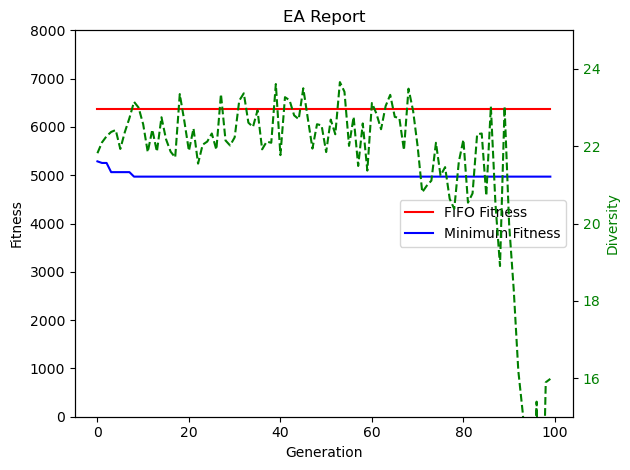

In [43]:
# Main execution function
def run_ea_tests():
    analyzer = EAAnalyzer(scheduler, toolbox)
    results = analyzer.run_tests(n_runs=1, verbose=True)
    analyzer.generate_report(1)
    return analyzer

run_ea_tests()

#### Parameter Tuning
At the problem solving layers (algorithm and application), decisions were made using the thought processes explained above, without explicit use of a utility function. However, for two of the symbolic parameters (recombination and parent selection), more than one algorithm was determined to be useful for this problem. For recombination, the order-one crossover is applied with a certain probability, and otherwise edge recombination is applied. For parent selection, stochastic universal sampling is used in early stages (up to a certain generation ratio), after which tournament selection is applied. This creates two numeric parameters which may be tuned along with the other parameters in the design layer.

At the design layer, initial parameter values were assigned through intuition and heuristics, leaving room for tuning by applying the GENERATE and TEST principle. These parameters were:
|                                                         |
|---------------------------------------------------------|
| Recombination probability                               |
| Mutation probability                                    |
| Tournament selection size                               |
| Generation switch threshold                             |
| Mixed crossover probability (order-one vs edge)         |
| Population size                                         |
| Fitness sharing radius                                  |
| Linear ranking selection pressure                       |

##### GENERATE
A non-iterative tuner was used to create a fixed set of vectors for each parameter which were then explored in the test step.

##### TEST
A single-stage procedure was applied to fully test a subset of parameter value combinations.

=== PARAMETER TUNING PROCEDURE ===
Phase 1: GENERATE - Creating parameter vectors
Generated 15 reduced parameter vectors to test

Phase 2: TEST - Testing 15 parameter vectors

Testing vector 1/15
Testing parameters: {'crossover_prob': 0.7, 'mutation_prob': 0.5, 'tournament_size': 2, 'generation_switch_threshold': 0.9, 'mixed_crossover_prob': 0.7, 'population_size': 15, 'sigma_share': 1.5, 'linear_ranking_s': 2.5}
Starting EA analysis...

=== Run 1/2 ===
Run 1 completed in 0.20s
Best fitness: 5029.00

=== Run 2/2 ===
Run 2 completed in 0.20s
Best fitness: 4973.00

=== Overall Results ===
Average runtime: 0.20 ± 0.00s
Best overall fitness: 4973.00
Optimized schedule:
Schedule Order:
  1. EJM83 (E550) - WT: 1
  2. SWA2397 (B737) - WT: 2
  3. EJA606 (C68A) - WT: 2
  4. EJA624 (C68A) - WT: 2
  5. SKW3352 (E75L) - WT: 2
  6. EJA11CA (C560) - WT: 2
  7. SKW3429 (E170) - WT: 2
  8. DLH467 (A359) - WT: 4
  9. JAL65 (B789) - WT: 3
  10. EJA874 (C700) - WT: 1
  Avg fitness: 5001.00 ± 28.00
  Best

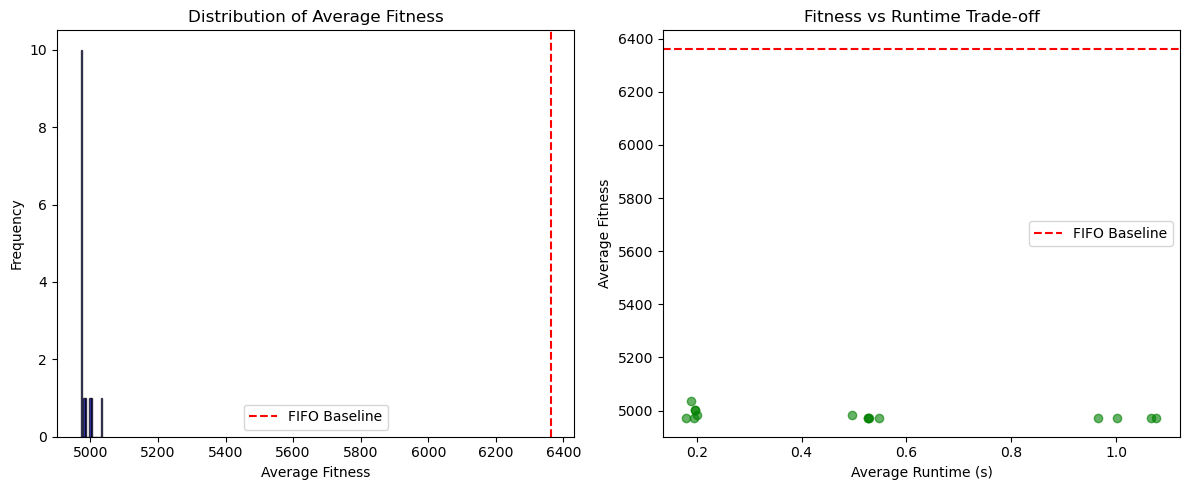

In [46]:
class ParameterTuner:
    def __init__(self, scheduler, toolbox):
        self.scheduler = scheduler
        self.toolbox = toolbox
        self.results = []
        
        # Define default parameter ranges for tuning
        self.parameter_ranges = {
            'crossover_prob': [0.5, 0.7, 0.9],  # Recombination probability
            'mutation_prob': [0.1, 0.3, 0.5],   # Mutation probability
            'tournament_size': [2, 3, 5],        # Tournament selection size
            'generation_switch_threshold': [0.5, 0.7, 0.9],  # When to switch from ranking to tournament
            'mixed_crossover_prob': [0.3, 0.5, 0.7],  # Probability of order-one vs edge recombination
            'population_size': [15, 30, 45],     # Population size
            'sigma_share': [1.5, 2.0, 2.5],     # Fitness sharing radius
            'linear_ranking_s': [1.5, 2.0, 2.5] # Linear ranking selection pressure
        }
        
    def generate_parameter_vectors(self):
        # Generate all combinations (full factorial design)
        param_names = list(self.parameter_ranges.keys())
        param_values = list(self.parameter_ranges.values())
        
        parameter_vectors = []
        
        # Create all combinations
        for combo in itertools.product(*param_values):
            param_vector = dict(zip(param_names, combo))
            parameter_vectors.append(param_vector)
        
        print(f"Generated {len(parameter_vectors)} parameter vectors to test")
        return parameter_vectors
    
    def generate_reduced_parameter_vectors(self, n_samples=50):
        #A reduced set using Latin Hypercube-like sampling is used for computational efficiency

        # Randomly sample combinations from self.parameter_ranges
        param_names = list(self.parameter_ranges.keys())
        parameter_vectors = []
        
        for _ in range(n_samples):
            param_vector = {}
            for param_name in param_names:
                param_vector[param_name] = np.random.choice(self.parameter_ranges[param_name])
            parameter_vectors.append(param_vector)
        
        print(f"Generated {len(parameter_vectors)} reduced parameter vectors to test")
        return parameter_vectors
    
    def test_parameter_vector(self, param_vector, n_runs=3):
        # Uses existing EAAnalyzer framework for consistency
        
        print(f"Testing parameters: {param_vector}")
        
        # Store original global parameters
        original_params = {
            'CROSSOVER_PROB': globals().get('CROSSOVER_PROB'),
            'MUTATION_PROB': globals().get('MUTATION_PROB'), 
            'TOURNAMENT_SIZE': globals().get('TOURNAMENT_SIZE'),
            'GENERATION_SWITCH_THRESHOLD': globals().get('GENERATION_SWITCH_THRESHOLD'),
            'POPULATION_SIZE': globals().get('POPULATION_SIZE'),
            'SIGMA_SHARE': globals().get('SIGMA_SHARE'),
            'LINEAR_RANKING_S': globals().get('LINEAR_RANKING_S'),
        }
        
        # Set new parameters
        globals().update({
            'POPULATION_SIZE': param_vector['population_size'],
            'CROSSOVER_PROB': param_vector['crossover_prob'],
            'MUTATION_PROB': param_vector['mutation_prob'],
            'TOURNAMENT_SIZE': param_vector['tournament_size'],
            'LINEAR_RANKING_S': param_vector['linear_ranking_s'],
            'SIGMA_SHARE': param_vector['sigma_share'],
            'GENERATION_SWITCH_THRESHOLD': param_vector['generation_switch_threshold'],
        })
        
        # Update toolbox population function to use new population size
        self.toolbox.register("population", create_seeded_population)
        
        # Use existing EAAnalyzer to run tests
        analyzer = EAAnalyzer(self.scheduler, self.toolbox)
        ea_results = analyzer.run_tests(n_runs=n_runs, verbose=False)
        
        # Extract results in format compatible with parameter tuning
        fitnesses = [result['best_fitness'] for result in ea_results['all_results']]
        runtimes = [result['runtime'] for result in ea_results['all_results']]
        
        result = {
            'parameters': param_vector.copy(),
            'avg_fitness': np.mean(fitnesses),
            'std_fitness': np.std(fitnesses),
            'best_fitness': min(fitnesses),
            'avg_runtime': ea_results['avg_runtime'],
            'std_runtime': ea_results['std_runtime'],
            'success_rate': 1.0,  # EAAnalyzer handles errors internally
            'ea_analyzer_results': ea_results
        }
        
        # Restore original parameters
        for param_name, param_value in original_params.items():
            if param_value is not None:
                globals()[param_name] = param_value
        
        return result
    
    def run_parameter_tuning(self, n_samples=20, n_runs=3):
        print("=== PARAMETER TUNING PROCEDURE ===")
        print("Phase 1: GENERATE - Creating parameter vectors")
        
        parameter_vectors = self.generate_reduced_parameter_vectors(n_samples)
    
        print(f"\nPhase 2: TEST - Testing {len(parameter_vectors)} parameter vectors")
        
        self.results = []
        total_vectors = len(parameter_vectors)
        
        for i, param_vector in enumerate(parameter_vectors):
            print(f"\nTesting vector {i+1}/{total_vectors}")
            result = self.test_parameter_vector(param_vector, n_runs)
            self.results.append(result)
            
            print(f"  Avg fitness: {result['avg_fitness']:.2f} ± {result['std_fitness']:.2f}")
            print(f"  Best fitness: {result['best_fitness']:.2f}")
            print(f"  Avg runtime: {result['avg_runtime']:.2f}s")
        
        return self.analyze_results()
    
    def analyze_results(self):
        # Extract data for plotting
        avg_fitnesses = [r['avg_fitness'] for r in self.results if r['avg_fitness'] != float('inf')]
        runtimes = [r['avg_runtime'] for r in self.results]
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        # Plot 1: Average fitness distribution
        ax1.hist(avg_fitnesses, bins=15, alpha=0.7, color='blue', edgecolor='black')
        ax1.axvline(FIFO_baseline, color='red', linestyle='--', label='FIFO Baseline')
        ax1.set_xlabel('Average Fitness')
        ax1.set_ylabel('Frequency')
        ax1.set_title('Distribution of Average Fitness')
        ax1.legend()
        
        # Plot: Best fitness vs runtime
        ax2.scatter(runtimes, avg_fitnesses, alpha=0.6, color='green')
        ax2.axhline(FIFO_baseline, color='red', linestyle='--', label='FIFO Baseline')
        ax2.set_xlabel('Average Runtime (s)')
        ax2.set_ylabel('Average Fitness')
        ax2.set_title('Fitness vs Runtime Trade-off')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

# Example usage function

#GENERATIONS parameter isn't tuned, but rather set at a lower value for all tuning runs to reduce computational complexity. In the original run of GENERATIONS = 100 with untuned parameters, less than 5 runs were needed for solution to be found.
GENERATIONS = 50
def run_parameter_tuning():
    tuner = ParameterTuner(scheduler, toolbox)
    
    # Run parameter tuning
    analysis = tuner.run_parameter_tuning(
        n_samples=15,        # Test 15 different parameter combinations
        n_runs=2             # 2 runs per combination for statistical validity
    )
    
    return tuner, analysis


tuner, analysis = run_parameter_tuning()

#### Conclusion
The challenge of minimizing wait times at congested airport runways is both operationally significant and computationally complex. Traditional scheduling heuristics like FIFO, while simple, fail to exploit more efficient arrangements in scenarios governed by tight constraints and dynamic demand. This makes the case for EAs particularly compelling, as they offer a flexible, robust means of navigating the vast, NP-hard search space of feasible departure sequences. 

By mimicking natural selection through tailored design choices—such as permutation-based representation, adaptive parent selection, and diversity-preserving mechanisms—EAs can iteratively converge toward departure schedules that reduce cumulative wait times while respecting all safety and operational constraints. As air traffic systems continue to grow in scale and complexity, EAs stand out as a powerful decision-support tool capable of transforming runway scheduling into a more intelligent and adaptable process.)

NOTE: One interesting problem that emerged during the coding of this EA was the use of both fitness sharing and linear ranking to temporarily change the fitness values of individuals before implementing parent selection. In this way, fitness sharing still occurs, but only impacts the probability of being selected during stochastic universal sampling if it impacts the fitness calculation enough to bring some individuals with shared fitnesses to a lower ranking than individuals in less-populated niches.
Fitness sharing prevents the population from converging to a single peak, while linear ranking ensures reasonable selection pressure regardless of fitness distribution. This produces complementary effects:

+ Even if fitness sharing creates very small fitness differences, linear ranking ensures they translate to meaningful selection probability differences
+ Controlled Exploration: In early generations, both mechanisms promote exploration. After the switch to tournament selection, there is more exploitation even though fitness sharing still occurs.

#### Sources:
Bianco, Lucio, Paolo Dell’Olmo, and Stefano Giordani. “Scheduling Models for Air Traffic Control in Terminal Areas.” Journal of scheduling 9.3 (2006): 223–253. Web.

Bianco, L. and Bielli, M. (1992), Air traffic management: Optimization models and algorithms. J. Adv. Transp., 26: 131-167. https://doi.org/10.1002/atr.5670260205

Here’s the APA 7th edition citation for that article:

Caprì, S., & Ignaccolo, M. (2004). Genetic algorithms for solving the aircraft-sequencing problem: The introduction of departures into the dynamic model. Journal of Air Transport Management, 10(5), 345–351. https://doi.org/10.1016/j.jairtraman.2004.05.004


Farrahi, Amir & Goldberg, Alan & Bagasol, Leonard & Jung, Jaewoo. (2017). Applying Graph Theory to Problems in Air Traffic Management. 10.2514/6.2017-3775. 

Grunewald, E., Knabe, F., Rudolph, F., & Schultz, M. (2017). Priority rules as a concept for the usage of scarce airport capacity. Transportation Research Procedia, 27, 1146–1153. https://doi.org/10.1016/j.trpro.2017.12.037

Hexaly. (n.d.). Flexible Job Shop Scheduling Problem with Sequence-Dependent Setup Times (FJSP-SDST). Hexaly. https://www.hexaly.com/docs/last/exampletour/flexible-job-shop-scheduling-problem-sequence-dependent-setup-times-fjsp-sdst.html

Robinson III, John & Davis, Thomas & Isaacson, Doug. (1997). A fuzzy reasoning-based sequencing of arrival aircraft in the terminal area. 10.2514/6.1997-3542. 
